In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

import torch
import torch_geometric as pyg

from baseline_evals.feature_selection import variance_filtering

from torch_geometric.utils import to_networkx


from bipartite_gnn.train_test import GNNTrainer
from bipartite_gnn.model import GAT_2L, BipartiteRGAT
from bipartite_gnn.graph_building import cosine_similarity_matrix

In [4]:
null_vals = ["NA"]
mrna = pl.read_csv("BRCA_PROCESSED_DATA/mrna.tsv", separator="\t", null_values=null_vals)
cna = pl.read_csv("BRCA_PROCESSED_DATA/cnvth.tsv", separator="\t", null_values=null_vals)
mirna = pl.read_csv("BRCA_PROCESSED_DATA/mirna.tsv", separator="\t", null_values=null_vals)

labels = pl.read_csv("BRCA_PROCESSED_DATA/labels.tsv", separator="\t")
le = LabelEncoder()
le.fit(labels["PAM50_mRNA_nature2012"].to_list())
y = le.transform(labels["PAM50_mRNA_nature2012"].to_list())
# labels, y

In [5]:
# mrna, cna, mirna
mrna_gene_names = mrna[:, 0].to_list()
cna_gene_names = cna[:, 0].to_list()
mirna_gene_names = mirna[:, 0].to_list()

In [6]:
mrna_X = torch.tensor(mrna[:, 1:].to_numpy().T)
cna_X = torch.tensor(cna[:, 1:].to_numpy().T)
mirna_X = torch.tensor(mirna[:, 1:].to_numpy().T)

In [7]:
mrna_X.shape

torch.Size([483, 18975])

In [8]:
train_mask, test_mask = train_test_split(torch.arange(len(y)), test_size=0.2, stratify=y, random_state=3)
val_mask, test_mask = train_test_split(test_mask, test_size=0.5, random_state=3)

In [9]:
# select 400 top genes for mrna
select_mask = variance_filtering(mrna_X.numpy(), 400)
mrna_X_400 = mrna_X[:, select_mask]

# normalize mrna_X_400
mm_scaler = MinMaxScaler()
mm_scaler.fit(mrna_X_400.numpy()[train_mask])

mrna_X_400 = torch.tensor(mm_scaler.transform(mrna_X_400.numpy()))

# select 400 top genes for cna
select_mask = variance_filtering(cna_X.numpy(), 400)
cna_X_400 = cna_X[:, select_mask].float()

# select 200 top genes for mirna
select_mask = variance_filtering(mirna_X.numpy(), 200)
mirna_X_200 = mirna_X[:, select_mask]

In [10]:
# create hetero-data object
from bipartite_gnn.graph_building import create_diff_exp_connections_nbnom, create_diff_exp_connections_norm, dense_to_coo
import torch_geometric.transforms as T

data = pyg.data.HeteroData()

proj_dim = 128

# sample node features
data["mrna"].x = mrna_X_400.float()
# data["cna"].x = cna_X_400.float()
# data["mirna"].x = mirna_X_200.float()

data.y = torch.tensor(y)
# data["mrna"].y = data["cna"].y = data["mirna"].y = torch.tensor(y)

data.omics = ["mrna"] #, "cna", "mirna"]

# feature node projection
data["mrna_feature"].x = torch.ones(mrna_X_400.shape[1], proj_dim)
# data["cna_feature"].x = torch.ones(cna_X_400.shape[1], proj_dim)
# data["mirna_feature"].x = torch.ones(mirna_X_200.shape[1], proj_dim)

# create edges
data.num_relations = 2 # 3 for forward egdes, 3 for backward edges

mrna_A = create_diff_exp_connections_norm(mrna_X_400, 3.0)

print("isolated samples, isolated genes")
print((mrna_A.abs().sum(axis=1) == 0).sum(), (mrna_A.abs().sum(axis=0) == 0).sum())

data["mrna", "diff_exp", "mrna_feature"].edge_index = dense_to_coo(mrna_A)
# data["cna", "diff_exp", "cna_feature"].edge_index = dense_to_coo(create_diff_exp_connections_norm(cna_X_400, 2.0))
# data["mirna", "diff_exp", "mirna_feature"].edge_index = dense_to_coo(create_diff_exp_connections_norm(mirna_X_200, 2.0))

data = T.ToUndirected()(data)
data = T.AddSelfLoops()(data)

data["train_mask"] = torch.tensor(train_mask)
data["val_mask"] = torch.tensor(val_mask)
data["test_mask"] = torch.tensor(test_mask)

data

isolated samples, isolated genes
tensor(100) tensor(34)


/tmp/ipykernel_285576/2925697403.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data["train_mask"] = torch.tensor(train_mask)
/tmp/ipykernel_285576/2925697403.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data["val_mask"] = torch.tensor(val_mask)
/tmp/ipykernel_285576/2925697403.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data["test_mask"] = torch.tensor(test_mask)


HeteroData(
  y=[483],
  omics=[1],
  num_relations=2,
  train_mask=[386],
  val_mask=[48],
  test_mask=[49],
  mrna={ x=[483, 400] },
  mrna_feature={ x=[400, 128] },
  (mrna, diff_exp, mrna_feature)={ edge_index=[2, 678] },
  (mrna_feature, rev_diff_exp, mrna)={ edge_index=[2, 678] }
)

In [11]:
# fit knn to mrna_X_400
from matplotlib.pyplot import cla
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

knn = LinearSVC(C=100, class_weight="balanced")
knn.fit(mrna_X_400.numpy()[train_mask], data.y[train_mask].numpy())

# predict on the test set
y_pred = knn.predict(mrna_X_400.numpy()[test_mask])

print(f"Accuracy: {accuracy_score(data.y[test_mask].numpy(), y_pred)}")

/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.7142857142857143


/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [12]:
from baseline_evals.mlp_eval import mlp_eval

mlp_eval(mrna_X_400, data.y, n_trials=10, val_test_size=0.4)

[I 2024-04-04 19:35:34,266] A new study created in memory with name: no-name-51125e56-efaa-4a5a-89fb-34c50ec17599


Trial 0 / 10
Eval 1 / 5


/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Eval 2 / 5
Eval 3 / 5
Eval 4 / 5
Eval 5 / 5


[I 2024-04-04 19:36:59,851] Trial 0 finished with value: 2.260812653372179 and parameters: {'l1_lambda': 0.03390523091109825, 'batch_sz': 32, 'proj_dim': 52, 'dropout': 0.27829297215268683, 'hidden_channels': 208}. Best is trial 0 with value: 2.260812653372179.


...

Trial 8 / 10
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5


[I 2024-04-04 19:45:06,223] Trial 8 finished with value: 1.3829829549046089 and parameters: {'l1_lambda': 0.005953851369294697, 'batch_sz': 32, 'proj_dim': 62, 'dropout': 0.4657741352037359, 'hidden_channels': 167}. Best is trial 4 with value: 2.4407210851365404.


Pruning trial after 2 evals, cause 0.7402102127574364 < 0.8141522537166663
Trial 9 / 10
Eval 1 / 5
Eval 2 / 5
Eval 3 / 5


[I 2024-04-04 19:45:53,055] Trial 9 finished with value: 1.2546653054871513 and parameters: {'l1_lambda': 0.017290779871547084, 'batch_sz': 64, 'proj_dim': 50, 'dropout': 0.3262176102368498, 'hidden_channels': 255}. Best is trial 4 with value: 2.4407210851365404.


Pruning trial after 2 evals, cause 0.6992129583256576 < 0.8141522537166663
study.best_value=2.4407210851365404, study.best_params={'l1_lambda': 0.0042866973447529075, 'batch_sz': 64, 'proj_dim': 111, 'dropout': 0.5678802411410948, 'hidden_channels': 199}
| MLP | 0.81 +/- 0.03 | 0.81 +/- 0.05 | 0.81 +/- 0.03 |


In [50]:
# build cosine similarity graph
from bipartite_gnn.graph_building import keep_n_neighbours


CSM = cosine_similarity_matrix(mrna_X_400)
print(CSM)
A = keep_n_neighbours(CSM, 5)
print(A)
data_csim = pyg.data.Data()

data_csim.x = mrna_X_400
data_csim.y = y
data_csim.edge_index = dense_to_coo(A)

tensor([[1.0000, 0.9593, 0.9483,  ..., 0.8746, 0.9491, 0.9321],
        [0.9593, 1.0000, 0.9539,  ..., 0.8619, 0.9354, 0.9544],
        [0.9483, 0.9539, 1.0000,  ..., 0.8541, 0.9310, 0.9148],
        ...,
        [0.8746, 0.8619, 0.8541,  ..., 1.0000, 0.8359, 0.8754],
        [0.9491, 0.9354, 0.9310,  ..., 0.8359, 1.0000, 0.9062],
        [0.9321, 0.9544, 0.9148,  ..., 0.8754, 0.9062, 1.0000]],
       dtype=torch.float64)
tensor([[  0,  40,  58, 378, 214],
        [  1, 334, 170,  63,  48],
        [  2, 327, 349,  41,  91],
        ...,
        [480, 213, 277,   9, 365],
        [481, 240, 389, 349,  55],
        [482, 360,   7, 463, 129]])
tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 2., 1.],
        [1., 1., 1.,  ..., 1., 1., 2.]], dtype=torch.float64)


In [48]:
A.sum()

tensor(2308.6475, dtype=torch.float64)

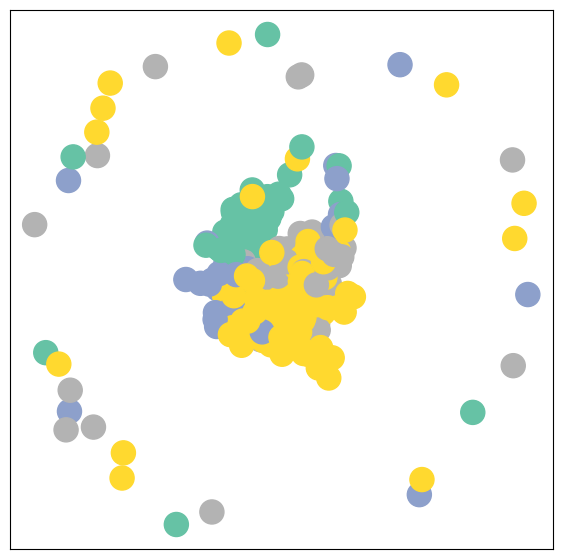

In [49]:
from bipartite_gnn.graph_visualizatons import visualize_graph

G = to_networkx(data_csim, to_undirected=True)
visualize_graph(G, color=data.y)

In [ ]:
model = GAT_2L()

In [235]:
dh = data.to_homogeneous()

In [220]:
dh

Data(y=[483], omics=[1], num_relations=2, train_mask=[386], val_mask=[48], test_mask=[49], edge_index=[2, 198172], x=[1483, 1000], node_type=[1483], edge_type=[198172])

In [225]:
model = BiGAT_2L(
    input_shape=dh.x.shape[1],
    n_classes=len(torch.unique(dh.y)),
    channels=64,
    heads=1,
)

model(dh)

tensor([[ 2.9351,  1.9941, -4.5037,  1.4931],
        [ 2.9637,  2.1310, -4.5704,  1.5750],
        [ 3.1081,  2.1612, -4.8691,  1.6995],
        ...,
        [ 3.1035,  2.1544, -4.8474,  1.8252],
        [ 3.1302,  2.1412, -4.7863,  1.7594],
        [ 3.2064,  2.3280, -4.9522,  1.8299]], grad_fn=<IndexBackward0>)

In [237]:
data = data.to_homogeneous()

In [252]:

model = BiGAT_2L(
    input_shape=dh.x.shape[1],
    n_classes=len(torch.unique(dh.y)),
    channels=64,
    heads=1,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data)  # Perform a single forward pass.
    mask = data.train_mask
    loss = criterion(out[mask], data.y[mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data)
    # print(out.argmax(dim=1))
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.

    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 11):
    # print(f'Epoch: {epoch:03d}')
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 1 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 001, Loss: 4.0908 Train acc 0.0019 Train f1 0.6263 Val acc 0.0024 Val f1 0.6849
Test Accuracy: 0.0016, test f1: 0.5588
Epoch: 002, Loss: 7.4069 Train acc 0.0010 Train f1 0.4017 Val acc 0.0006 Val f1 0.2222
Test Accuracy: 0.0015, test f1: 0.5373
Epoch: 003, Loss: 8.8057 Train acc 0.0016 Train f1 0.4902 Val acc 0.0022 Val f1 0.5693
Test Accuracy: 0.0016, test f1: 0.5027
Epoch: 004, Loss: 5.5914 Train acc 0.0016 Train f1 0.4927 Val acc 0.0022 Val f1 0.5693
Test Accuracy: 0.0016, test f1: 0.5027
Epoch: 005, Loss: 5.5302 Train acc 0.0014 Train f1 0.4066 Val acc 0.0010 Val f1 0.2394
Test Accuracy: 0.0017, test f1: 0.4909
Epoch: 006, Loss: 3.4359 Train acc 0.0008 Train f1 0.3072 Val acc 0.0012 Val f1 0.3773
Test Accuracy: 0.0007, test f1: 0.2309
Epoch: 007, Loss: 4.1724 Train acc 0.0010 Train f1 0.3460 Val acc 0.0013 Val f1 0.4004
Test Accuracy: 0.0009, test f1: 0.2889
Epoch: 008, Loss: 3.1076 Train acc 0.0012 Train f1 0.3947 Val acc 0.0006 Val f1 0.1883
Test Accuracy: 0.0017, test f1:

In [187]:
bigat = BiGAT_2L(
    input_shape=dh.x.shape[1],
    n_classes=len(torch.unique(dh.y)),
    channels=64,
    heads=1,
)

trainer = GNNTrainer(
    model=bigat,
    loss_fn=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(bigat.parameters(), lr=1e-3, weight_decay=5e-4),
    params={
        "l1_lambda" : 0.1,
    }
)

trainer.train(dh, epochs=10, log_interval=1)

AttributeError: 'GlobalStorage' object has no attribute 'x_dict'

In [155]:
model = BipartiteRGAT(
    input_sizes=[mrna_X_400.shape[1]], # , cna_X_400.shape[1], mirna_X_200.shape[1]],
    proj_dim=proj_dim,
    # proj_dropout=0.5,
    hidden_channels=[proj_dim, 64, 64], # num_layers = len(hidden_channels) - 1
    num_labels=len(np.unique(y)),
    num_relations=data.num_relations,
    num_bases=data.num_relations,
    num_heads=1,
    dropout=0.0,
    feature_integration_mode="linear",
)

trainer = GNNTrainer(
    model=model,
    loss_fn=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4),
    params={
        "l1_lambda" : 0.1,
    }
)

trainer.train(
    data=data,
    n_epochs=5,
    log_interval=1,
)

torch.Size([1, 483, 64])
torch.Size([1, 483, 64])
torch.Size([1, 483, 64])
Epoch: 001, 
Train Loss: 205.9656, Train Acc: 0.1788, Train F1 Macro: 0.0758, Train F1 Weighted: 0.0542
Val Loss: 13.5799, Val Acc: 0.5208, Val F1 Macro: 0.1712, Val F1 Weighted: 0.3567
Test Loss: 15.5119, Test Acc: 0.3878, Test F1 Macro: 0.1397, Test F1 Weighted: 0.2167
##################################################
torch.Size([1, 483, 64])
torch.Size([1, 483, 64])
torch.Size([1, 483, 64])
Epoch: 002, 
Train Loss: 209.3679, Train Acc: 0.4560, Train F1 Macro: 0.1566, Train F1 Weighted: 0.2856
Val Loss: 8.5750, Val Acc: 0.5208, Val F1 Macro: 0.1712, Val F1 Weighted: 0.3567
Test Loss: 6.7460, Test Acc: 0.3878, Test F1 Macro: 0.1397, Test F1 Weighted: 0.2167
##################################################
torch.Size([1, 483, 64])


KeyboardInterrupt: 

In [ ]:
model(data.clone()).shape

Data(omics=[3], num_relations=6, edge_index=[2, 13842], x=[2449, 128], y=[2449], node_type=[2449], edge_type=[13842])
torch.Size([3, 483, 64])


torch.Size([483])

In [11]:
dh = data.to_homogeneous()

HeteroData(
  num_relations=6,
  mrna={
    x=[483, 400],
    y=[483],
  },
  cna={
    x=[483, 400],
    y=[483],
  },
  mirna={
    x=[483, 200],
    y=[483],
  },
  mrna_feature={ x=[18975, 128] },
  cna_feature={ x=[24776, 128] },
  mirna_feature={ x=[231, 128] },
  (mrna, diff_exp, mrna_feature)={ edge_index=[2, 3730] },
  (cna, diff_exp, cna_feature)={ edge_index=[2, 1997] },
  (mirna, diff_exp, mirna_feature)={ edge_index=[2, 1194] },
  (mrna_feature, rev_diff_exp, mrna)={ edge_index=[2, 3730] },
  (cna_feature, rev_diff_exp, cna)={ edge_index=[2, 1997] },
  (mirna_feature, rev_diff_exp, mirna)={ edge_index=[2, 1194] }
)

In [12]:
dh

Data(num_relations=6, edge_index=[2, 13842], x=[45431, 400], y=[45431], node_type=[45431], edge_type=[13842])

In [47]:
data

HeteroData(
  mrna={
    x=[483, 18975],
    y=[483],
  },
  cna={
    x=[483, 24776],
    y=[483],
  },
  mirna={
    x=[483, 231],
    y=[483],
  },
  mrna_feature={ x=[18975, 128] },
  cna_feature={ x=[24776, 128] },
  mirna_feature={ x=[231, 128] }
)

In [48]:
mrna_X.shape, cna_X.shape, mirna_X.shape

(torch.Size([483, 18975]), torch.Size([483, 24776]), torch.Size([483, 231]))

In [49]:
dh

Data(x=[45431, 24776], y=[45431], node_type=[45431])

In [50]:
# get counts of unique values in the dh.node_type tensor
node_type_counts = torch.unique(dh.node_type, return_counts=True)
node_type_counts

(tensor([0, 1, 2, 3, 4, 5]),
 tensor([  483,   483,   483, 18975, 24776,   231]))

In [19]:
data

HeteroData(
  mrna={
    x=[18975, 483],
    y=[483],
  },
  cna={
    x=[24776, 483],
    y=[483],
  },
  mirna={
    x=[231, 483],
    y=[483],
  }
)

In [ ]:
# train the model